In [50]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [53]:
import kagglehub

In [54]:
train_data = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test_data = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')


In [55]:
print("Train Data:")
print(train_data.head())

Train Data:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008 

In [56]:
print("\nTest Data:")
print(test_data.head())


Test Data:
     Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0  1461          20       RH         80.0    11622   Pave   NaN      Reg   
1  1462          20       RL         81.0    14267   Pave   NaN      IR1   
2  1463          60       RL         74.0    13830   Pave   NaN      IR1   
3  1464          60       RL         78.0     9978   Pave   NaN      IR1   
4  1465         120       RL         43.0     5005   Pave   NaN      IR1   

  LandContour Utilities  ... ScreenPorch PoolArea PoolQC  Fence MiscFeature  \
0         Lvl    AllPub  ...         120        0    NaN  MnPrv         NaN   
1         Lvl    AllPub  ...           0        0    NaN    NaN        Gar2   
2         Lvl    AllPub  ...           0        0    NaN  MnPrv         NaN   
3         Lvl    AllPub  ...           0        0    NaN    NaN         NaN   
4         HLS    AllPub  ...         144        0    NaN    NaN         NaN   

  MiscVal MoSold  YrSold  SaleType  SaleCondition  
0   

In [57]:
train_data.shape

(1460, 81)

In [58]:
test_data.shape

(1459, 80)

In [59]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [60]:
missing_values = train_data.isnull().sum()

print(missing_values[missing_values > 0])

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [61]:
none_cols = [
    'Alley',
    'MasVnrType',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'FireplaceQu',
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'PoolQC',
    'Fence',
    'MiscFeature'
]

for col in none_cols:
    train_data[col] = train_data[col].fillna('None')

In [62]:
all_data = pd.concat([train_data.drop('SalePrice', axis=1), test_data], axis=0)

In [63]:
all_data.shape

(2919, 80)

In [64]:
none_cols = [
    'Alley',
    'MasVnrType',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'FireplaceQu',
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'PoolQC',
    'Fence',
    'MiscFeature'
]

for col in none_cols:
    all_data[col] = all_data[col].fillna('None')

In [65]:
all_data[none_cols].isnull().sum()

Alley           0
MasVnrType      0
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
FireplaceQu     0
GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
PoolQC          0
Fence           0
MiscFeature     0
dtype: int64

In [66]:
missing_values = all_data.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

LotFrontage     486
GarageYrBlt     159
MasVnrArea       23
MSZoning          4
Utilities         2
BsmtFullBath      2
Functional        2
BsmtHalfBath      2
Exterior1st       1
Exterior2nd       1
BsmtFinSF1        1
Electrical        1
TotalBsmtSF       1
BsmtUnfSF         1
BsmtFinSF2        1
KitchenQual       1
GarageCars        1
GarageArea        1
SaleType          1
dtype: int64

In [67]:
zero_cols = [
    'GarageYrBlt',
    'MasVnrArea'
]

for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)

In [68]:
all_data[zero_cols].isnull().sum()

GarageYrBlt    0
MasVnrArea     0
dtype: int64

In [69]:
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

In [70]:
all_data['LotFrontage'].isnull().sum()

np.int64(0)

In [71]:
missing_values = all_data.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

MSZoning        4
Utilities       2
BsmtHalfBath    2
BsmtFullBath    2
Functional      2
BsmtFinSF1      1
Exterior1st     1
Exterior2nd     1
TotalBsmtSF     1
BsmtUnfSF       1
BsmtFinSF2      1
Electrical      1
KitchenQual     1
GarageCars      1
GarageArea      1
SaleType        1
dtype: int64

In [72]:
id_cols = [
    'MSZoning',
    'Utilities',
    'BsmtHalfBath',
    'BsmtFullBath',
    'Functional',
    'BsmtFinSF1',
    'Exterior1st',
    'Exterior2nd',
    'TotalBsmtSF',
    'BsmtUnfSF',
    'BsmtFinSF2',
    'Electrical',
    'KitchenQual',
    'GarageCars',
    'GarageArea',
    'SaleType'
]

all_data[id_cols].dtypes

MSZoning         object
Utilities        object
BsmtHalfBath    float64
BsmtFullBath    float64
Functional       object
BsmtFinSF1      float64
Exterior1st      object
Exterior2nd      object
TotalBsmtSF     float64
BsmtUnfSF       float64
BsmtFinSF2      float64
Electrical       object
KitchenQual      object
GarageCars      float64
GarageArea      float64
SaleType         object
dtype: object

In [73]:
object_cols = [
    'MSZoning',
    'Utilities',
    'Functional',
    'Exterior1st',
    'Exterior2nd',
    'Electrical',
    'KitchenQual',
    'SaleType'
]

for col in object_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

In [74]:
numeric_cols = [
    'BsmtHalfBath',
    'BsmtFullBath',
    'BsmtFinSF1',
    'TotalBsmtSF',
    'BsmtUnfSF',
    'BsmtFinSF2',
    'GarageCars',
    'GarageArea'
]

for col in numeric_cols:
    all_data[col] = all_data[col].fillna(all_data[col].median())

In [75]:
all_data.isnull().sum().sum()

np.int64(0)

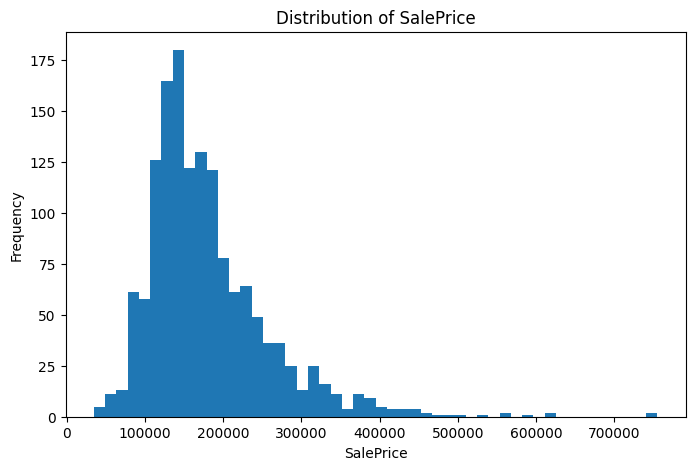

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(train_data['SalePrice'], bins=50)
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.title('Distribution of SalePrice')
plt.show()

In [77]:
train_data['SalePrice'].skew()

np.float64(1.8828757597682129)

In [78]:
train_data['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [79]:
import numpy as np

train_data['SalePrice'] = np.log1p(train_data['SalePrice'])

In [80]:
train_data['SalePrice'].skew()

np.float64(0.12134661989685333)

In [81]:
all_data.select_dtypes(include=['object']).columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [82]:
all_data = pd.get_dummies(all_data)

In [83]:
all_data.shape

(2919, 303)

In [84]:
X = all_data.iloc[:1460, :]
X_test = all_data.iloc[1460:, :]

y = train_data['SalePrice']

In [85]:
X.shape

(1460, 303)

In [86]:
X_test.shape

(1459, 303)

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [88]:
X_train.shape

(1168, 303)

In [89]:
X_valid.shape

(292, 303)

In [90]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [91]:
from sklearn.linear_model import LinearRegression

In [92]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [95]:
y_pred = model.predict(X_valid)

In [96]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

rmse

np.float64(0.13223154548653476)

In [97]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [98]:
rf_pred = rf_model.predict(X_valid)

In [99]:
rf_rmse = np.sqrt(mean_squared_error(y_valid, rf_pred))

rf_rmse

np.float64(0.14579998040054332)

In [100]:
all_data['TotalSF'] = (
    all_data['TotalBsmtSF'] +
    all_data['1stFlrSF'] +
    all_data['2ndFlrSF']
)

In [101]:
all_data[['TotalSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF']].head()

,TotalSF,TotalBsmtSF,1stFlrSF,2ndFlrSF
0,2566.0,856.0,856,854
1,2524.0,1262.0,1262,0
2,2706.0,920.0,920,866
3,2473.0,756.0,961,756
4,3343.0,1145.0,1145,1053


In [102]:
all_data['TotalBathrooms'] = (
    all_data['FullBath'] +
    0.5 * all_data['HalfBath'] +
    all_data['BsmtFullBath'] +
    0.5 * all_data['BsmtHalfBath']
)

In [103]:
all_data[['TotalBathrooms','FullBath','HalfBath','BsmtFullBath','BsmtHalfBath']].head()

,TotalBathrooms,FullBath,HalfBath,BsmtFullBath,BsmtHalfBath
0,3.5,2,1,1.0,0.0
1,2.5,2,0,0.0,1.0
2,3.5,2,1,1.0,0.0
3,2.0,1,0,1.0,0.0
4,3.5,2,1,1.0,0.0


In [104]:
all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']

In [105]:
all_data[['HouseAge','YrSold','YearBuilt']].head()

,HouseAge,YrSold,YearBuilt
0,5,2008,2003
1,31,2007,1976
2,7,2008,2001
3,91,2006,1915
4,8,2008,2000


In [106]:
X = all_data.iloc[:1460, :]
X_test = all_data.iloc[1460:, :]

y = train_data['SalePrice']

In [107]:
X. shape

(1460, 306)

In [109]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [110]:
X_train.shape

(1168, 306)

In [111]:
from sklearn.linear_model import LinearRegression

model_fe = LinearRegression()

model_fe.fit(X_train, y_train)

LinearRegression()

In [114]:
y_pred_fe = model_fe.predict(X_valid)

In [115]:
rmse_fe = np.sqrt(mean_squared_error(y_valid, y_pred_fe))

rmse_fe

np.float64(0.13223154548657273)

In [116]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, random_state=42)

In [117]:
gbr_pred = gbr_model.predict(X_valid)

In [118]:
gbr_rmse = np.sqrt(mean_squared_error(y_valid, gbr_pred))

gbr_rmse

np.float64(0.14580077045625145)

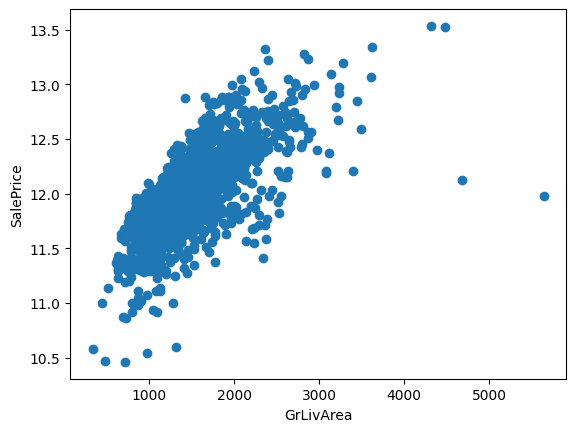

In [119]:
import matplotlib.pyplot as plt

plt.scatter(train_data['GrLivArea'], train_data['SalePrice'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()

In [120]:
train_data[['GrLivArea','SalePrice']].sort_values(
    by='GrLivArea',
    ascending=False
).head(10)

,GrLivArea,SalePrice
1298,5642,11.982935
523,4676,12.126764
1182,4476,13.521141
691,4316,13.534474
1169,3627,13.345509
185,3608,13.071072
304,3493,12.594734
1268,3447,12.850557
635,3395,12.206078
769,3279,13.195616


In [121]:
train_data.loc[
    (train_data['GrLivArea'] > 4000),
    ['GrLivArea','SalePrice']
]

,GrLivArea,SalePrice
523,4676,12.126764
691,4316,13.534474
1182,4476,13.521141
1298,5642,11.982935
